In [17]:
def visualize_model_weights(model, save_dir='weight_plots', show=True):
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    os.makedirs(save_dir, exist_ok=True)

    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue

        w = weights[0]
        name = layer.name

        if w.ndim == 4:
            n_filters = w.shape[-1]
            cols = min(8, n_filters)
            rows = (n_filters + cols - 1) // cols
            fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
            axes = np.array(axes).flatten()
            for i in range(n_filters):
                kernel = w[:, :, :, i].sum(axis=-1) if w.shape[2] > 1 else w[:, :, 0, i]
                axes[i].imshow(kernel, cmap='RdBu_r', aspect='auto')
                axes[i].set_title(f'F{i}', fontsize=8)
                axes[i].axis('off')
            for i in range(n_filters, len(axes)):
                axes[i].axis('off')
            fig.suptitle(f'{name} (Conv2D) — Filter Heatmaps\n{w.shape}', fontsize=10)
            fig.tight_layout()
            fig.savefig(os.path.join(save_dir, f'{name}_heatmaps.png'), dpi=150)
            if show:
                plt.show()
            plt.close(fig)

        elif w.ndim == 3:
            fig, ax = plt.subplots(figsize=(10, 4))
            reshaped = w.reshape(-1, w.shape[-1])
            im = ax.imshow(reshaped.T, cmap='RdBu_r', aspect='auto')
            ax.set_xlabel('Kernel × Input Channels')
            ax.set_ylabel('Output Filters')
            ax.set_title(f'{name} (Conv1D) — {w.shape}')
            plt.colorbar(im, ax=ax)
            fig.tight_layout()
            fig.savefig(os.path.join(save_dir, f'{name}.png'), dpi=150)
            if show:
                plt.show()
            plt.close(fig)

        elif w.ndim == 2:
            fig, ax = plt.subplots(figsize=(10, 6))
            im = ax.imshow(w, cmap='RdBu_r', aspect='auto')
            ax.set_xlabel('Output Units')
            ax.set_ylabel('Input Units')
            ax.set_title(f'{name} (Dense) — {w.shape}')
            plt.colorbar(im, ax=ax)
            fig.tight_layout()
            fig.savefig(os.path.join(save_dir, f'{name}.png'), dpi=150)
            if show:
                plt.show()
            plt.close(fig)

        fig, ax = plt.subplots(figsize=(6, 3))
        ax.hist(w.flatten(), bins=100, color='steelblue', edgecolor='none')
        ax.set_title(f'{name} — Weight Distribution (mean={w.mean():.4f}, std={w.std():.4f})')
        ax.axvline(0, color='red', linestyle='--', alpha=0.5)
        fig.tight_layout()
        fig.savefig(os.path.join(save_dir, f'{name}_hist.png'), dpi=150)
        if show:
            plt.show()
        plt.close(fig)

def plot_all_layer_activations(model, x_sample):
    """Plot activations of ALL layers for a single sample.
    
    Args:
        model: trained keras model
        x_sample: input tensor, shape (1, timesteps, features)
    """
    # Skip input layer
    layer_outputs = []
    layer_names = []
    
    for layer in model.layers:
        if layer.__class__.__name__ == 'InputLayer':
            continue
        try:
            sub_model = tf.keras.Model(inputs=model.input, outputs=layer.output)
            act = sub_model.predict(x_sample, verbose=0)
            layer_outputs.append(act)
            layer_names.append(f"{layer.name} ({layer.__class__.__name__})")
        except Exception as e:
            print(f"Skipping {layer.name}: {e}")
    
    n = len(layer_outputs)
    fig, axes = plt.subplots(n, 1, figsize=(16, 2.5 * n))
    if n == 1:
        axes = [axes]
    
    for ax, act, name in zip(axes, layer_outputs, layer_names):
        act = np.squeeze(act, axis=0)  # remove batch dim
        
        if act.ndim == 3:
            # (H, W, C) or similar — flatten to 2D
            h, w, c = act.shape
            act_2d = act.reshape(h * w, c)
            im = ax.imshow(act_2d.T, aspect='auto', interpolation='nearest', cmap='viridis')
            ax.set_ylabel('Channel')
            ax.set_xlabel('Spatial (flattened)')
            plt.colorbar(im, ax=ax, fraction=0.02)
        elif act.ndim == 2:
            # (time, channels)
            im = ax.imshow(act.T, aspect='auto', interpolation='nearest', cmap='viridis')
            ax.set_ylabel('Channel')
            ax.set_xlabel('Time')
            plt.colorbar(im, ax=ax, fraction=0.02)
        elif act.ndim == 1:
            # dense / output
            ax.bar(range(len(act)), act, width=1.0, edgecolor='none')
            ax.set_xlabel('Unit')
            ax.set_ylabel('Activation')
            ax.set_xlim(-0.5, len(act) - 0.5)
        elif act.ndim == 0:
            ax.text(0.5, 0.5, f"Scalar: {float(act):.6f}", 
                    transform=ax.transAxes, ha='center', va='center', fontsize=14)
        else:
            # 4D+ — take mean over extra dims
            while act.ndim > 2:
                act = act.mean(axis=0)
            im = ax.imshow(act.T if act.ndim == 2 else act[np.newaxis, :], 
                          aspect='auto', cmap='viridis')
            plt.colorbar(im, ax=ax, fraction=0.02)
        
        # Add stats to title
        act_flat = np.squeeze(act).flatten()
        stats = f"min={act_flat.min():.3f} max={act_flat.max():.3f} mean={act_flat.mean():.3f} std={act_flat.std():.3f}"
        ax.set_title(f"{name}  shape={np.squeeze(act).shape}  [{stats}]", fontsize=9)
    
    plt.tight_layout()
    plt.savefig("all_layer_activations.png", dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Plotted {n} layers. Saved all_layer_activations.png")


# Usage:
#plot_all_layer_activations(cnn_model, x)



Image height:  148
Before string split: (1, 148, 32), max_x=148.0
freq_compress_conv2d/kernel
freq_compress_conv2d/bias


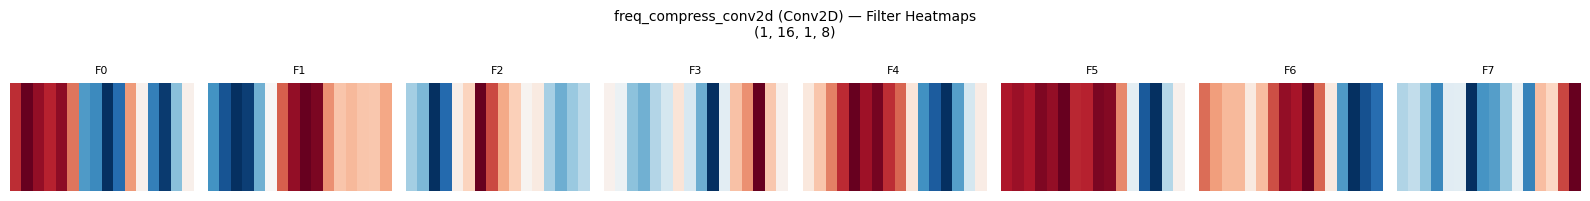

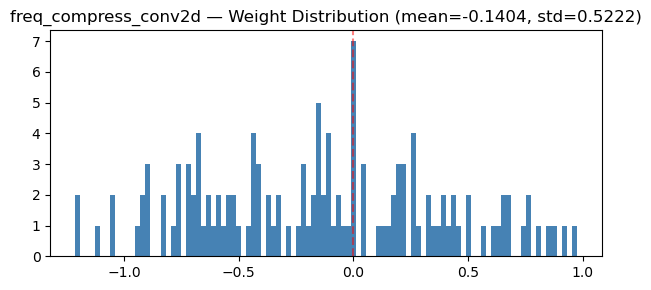

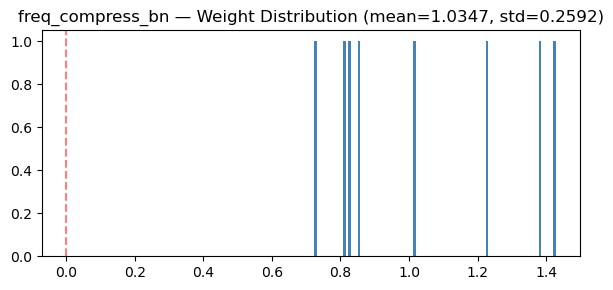

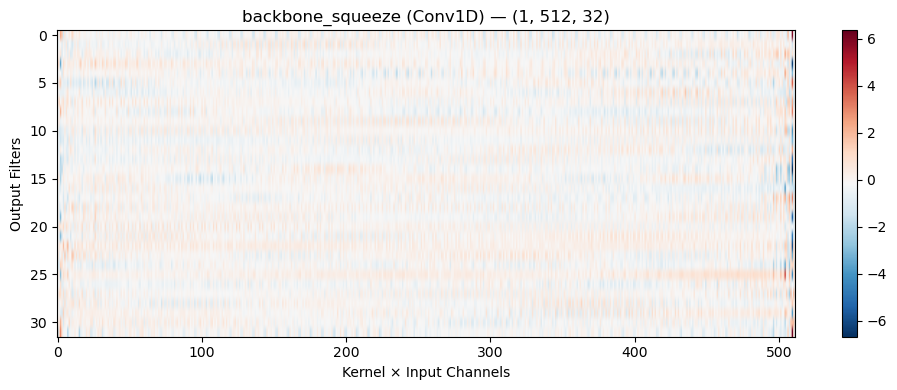

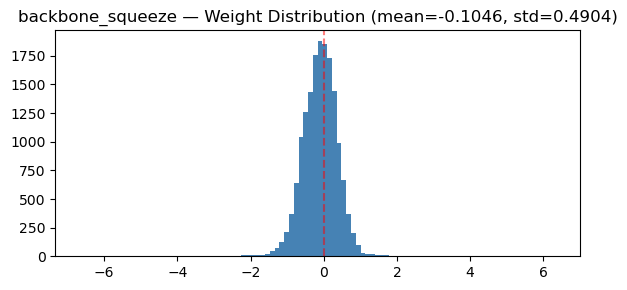

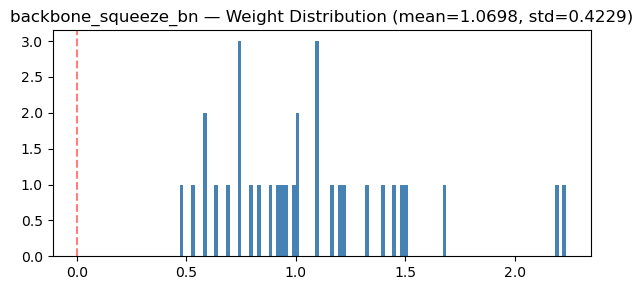

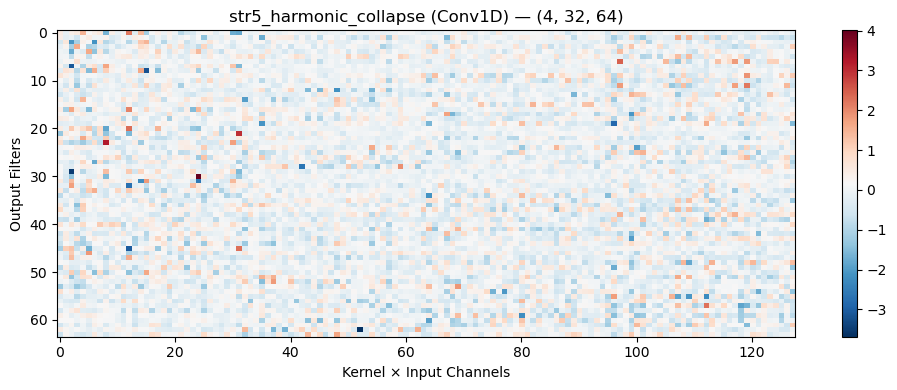

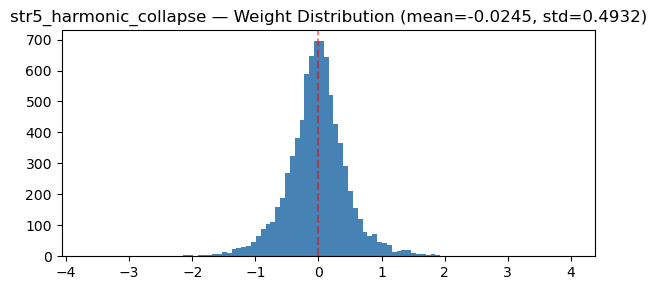

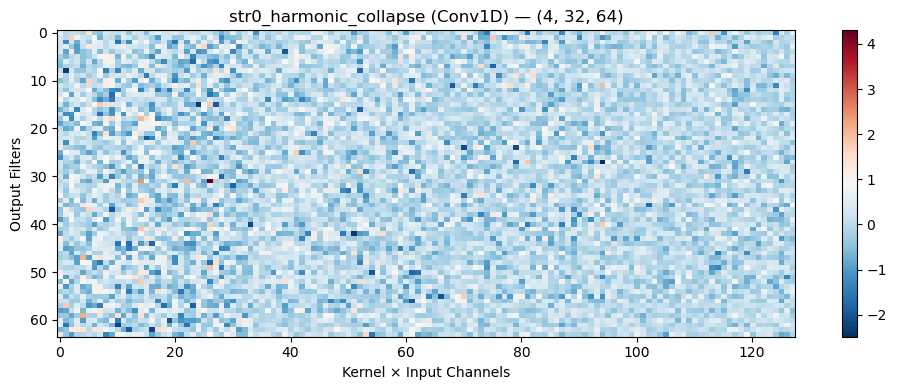

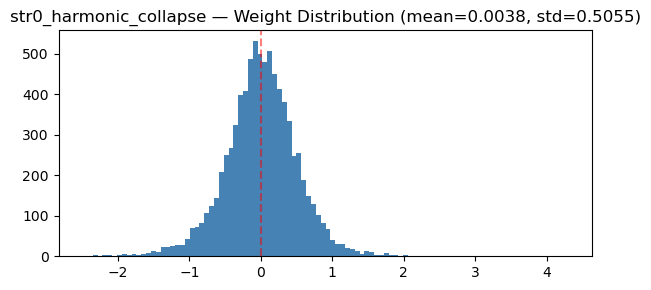

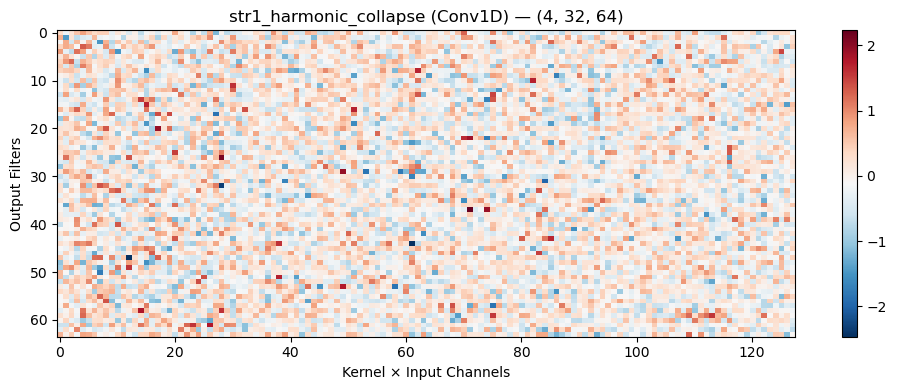

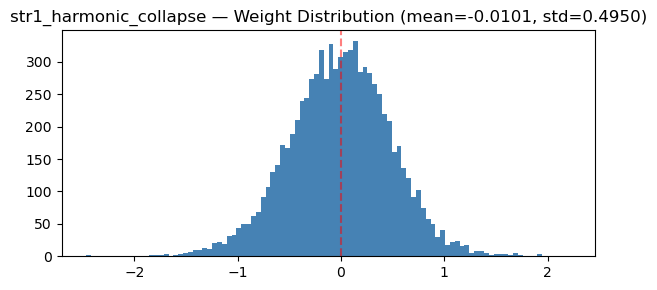

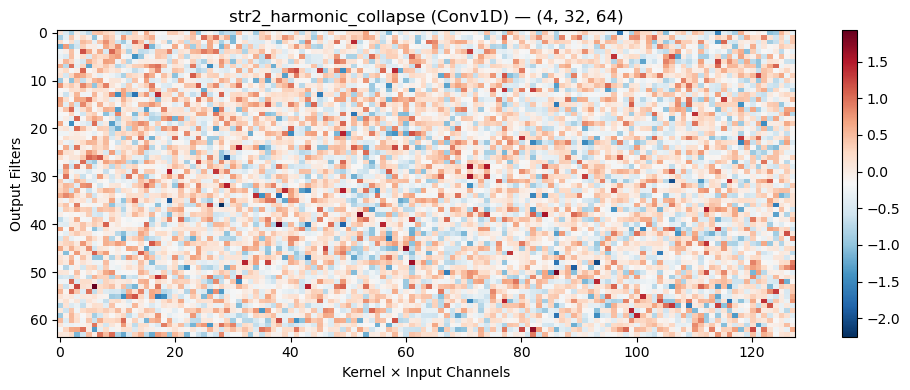

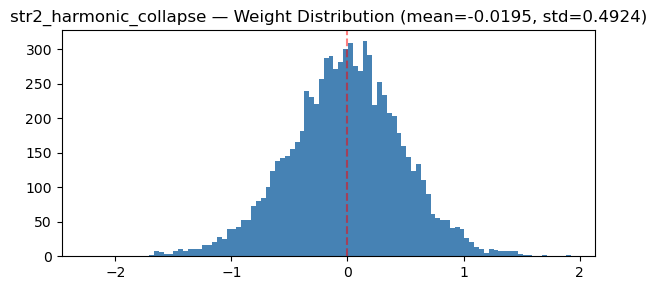

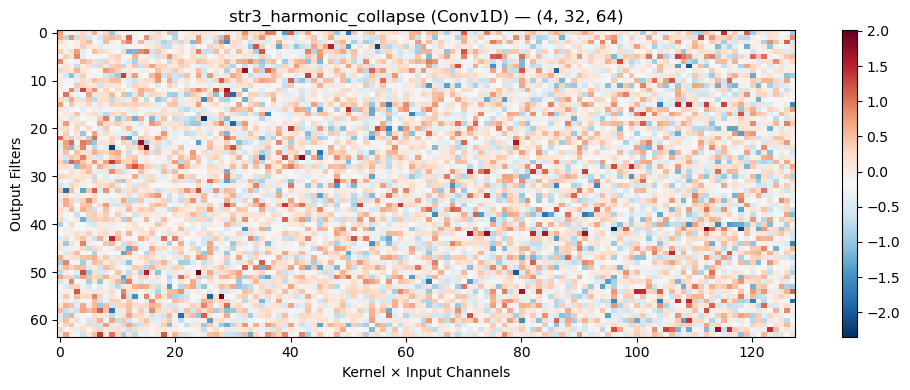

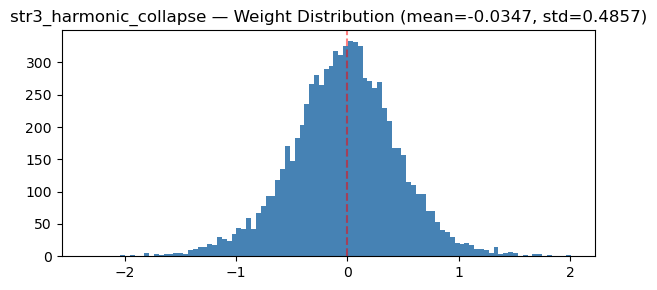

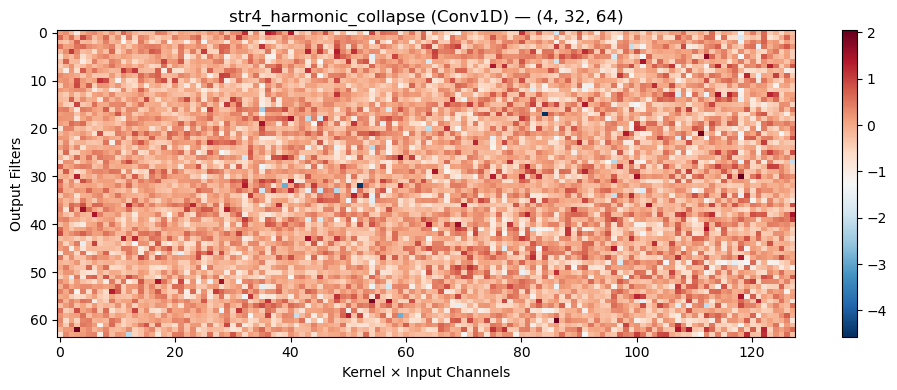

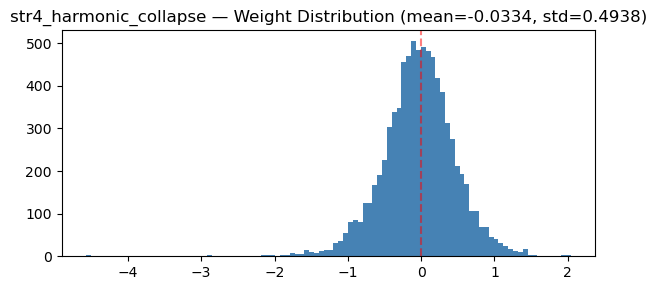

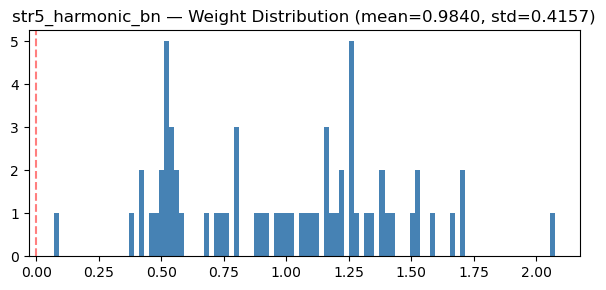

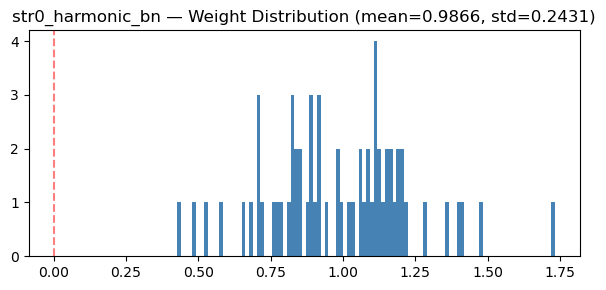

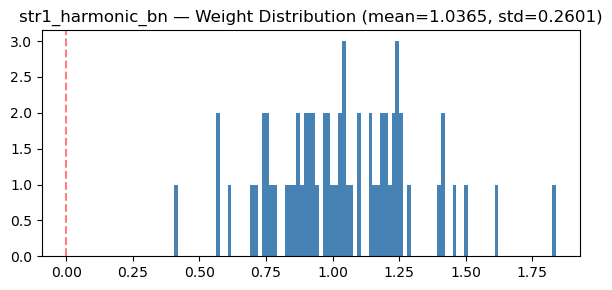

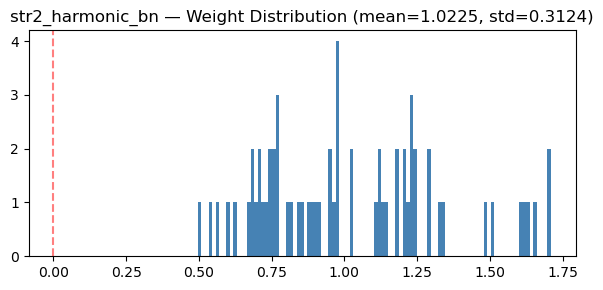

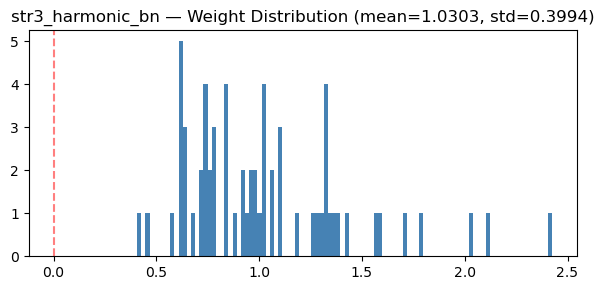

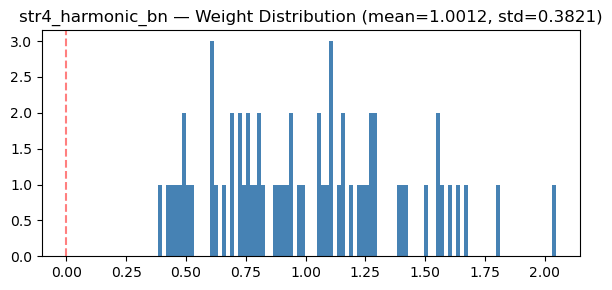

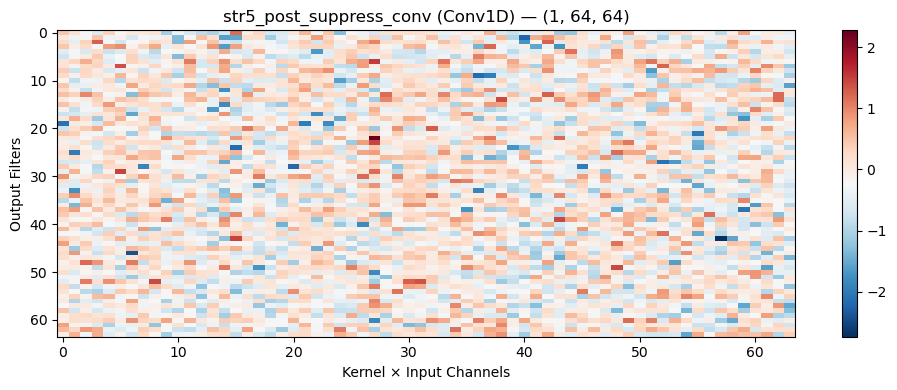

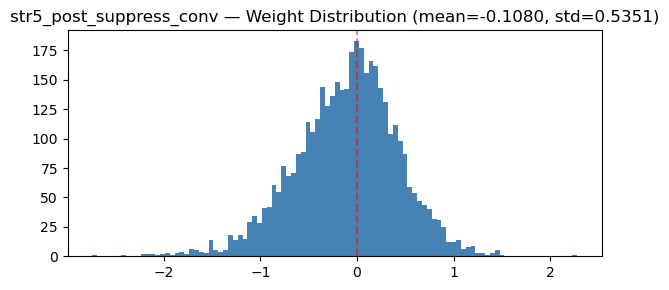

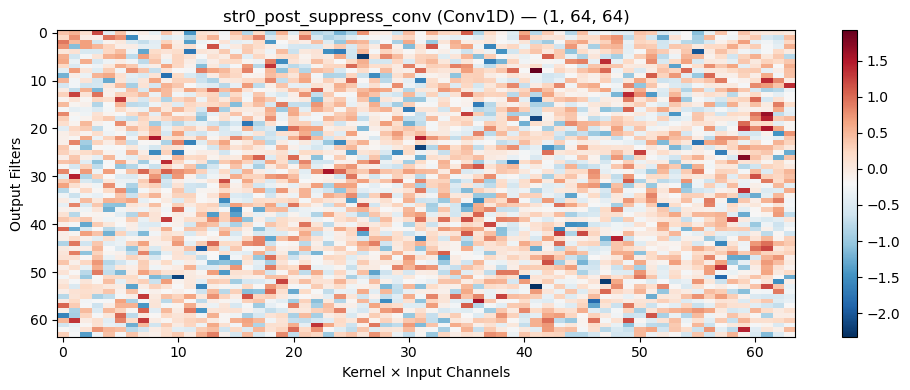

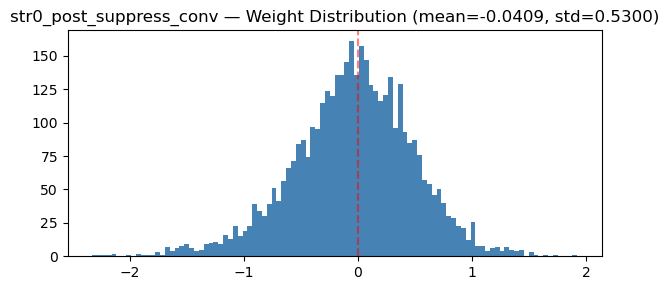

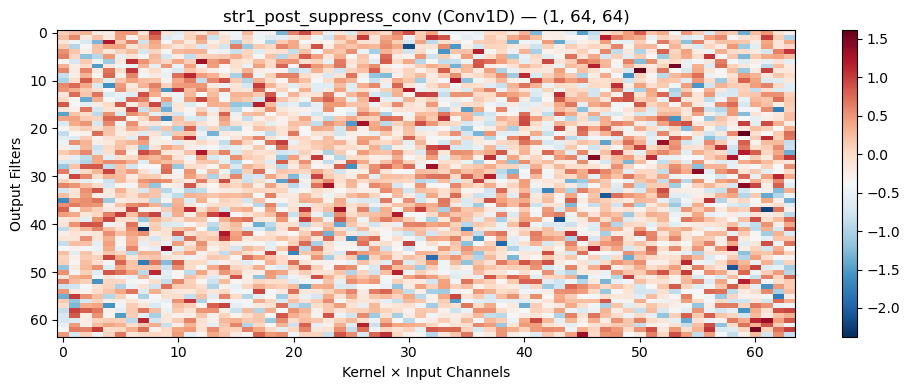

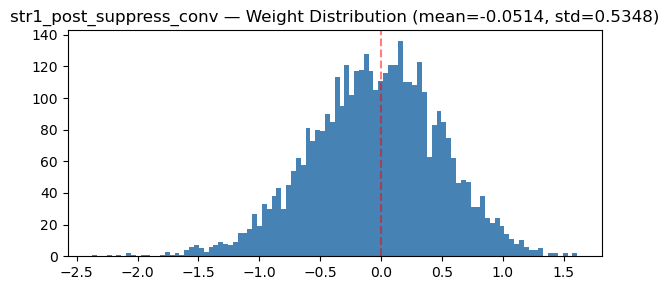

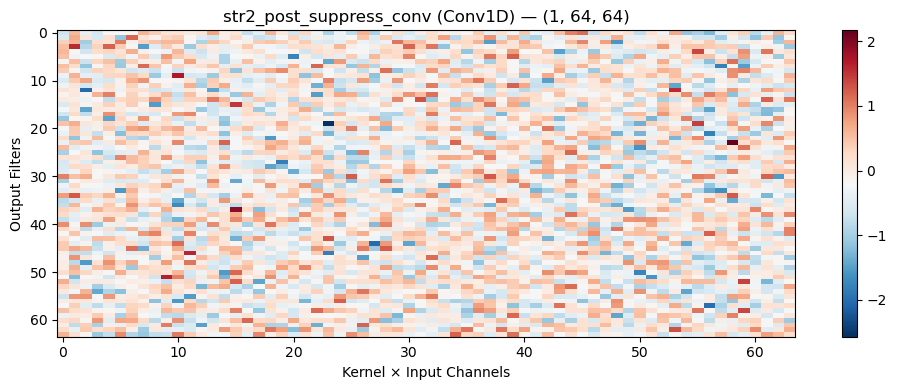

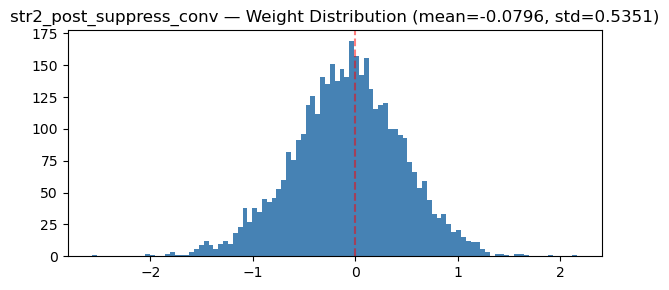

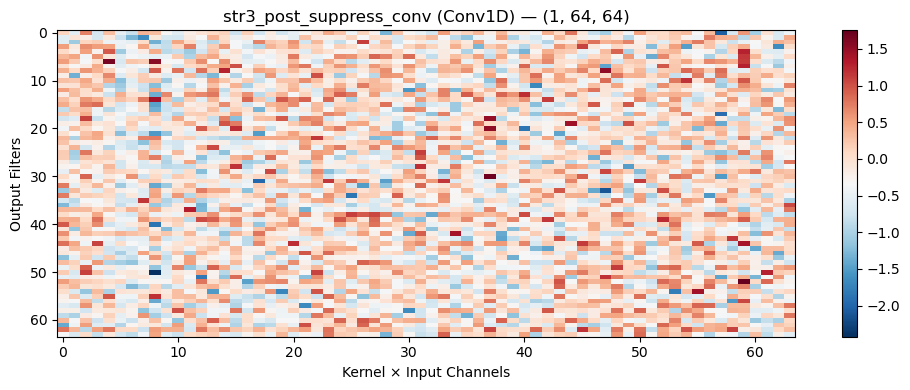

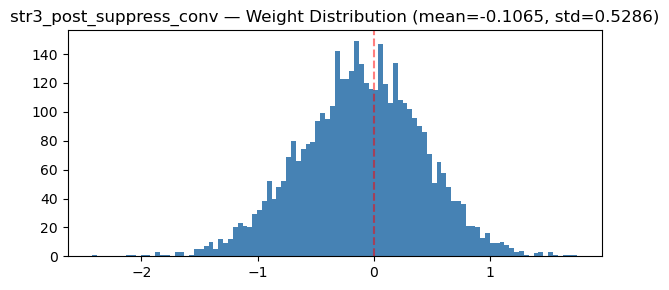

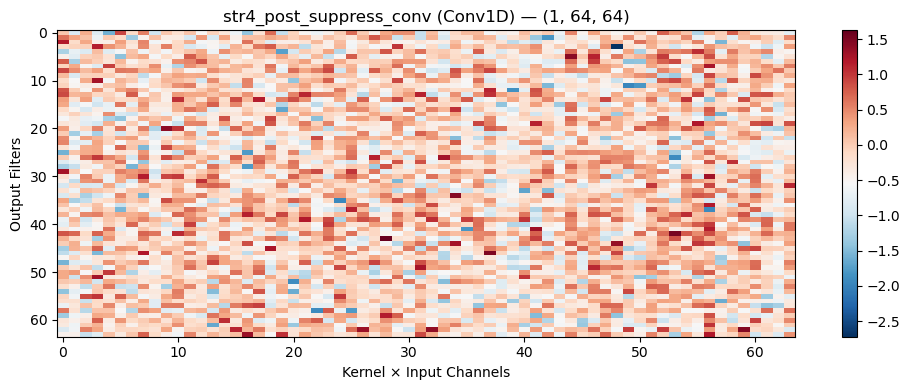

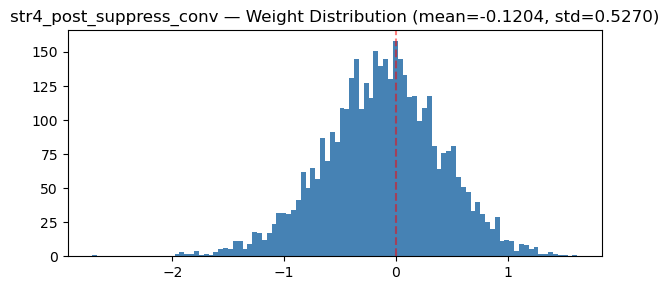

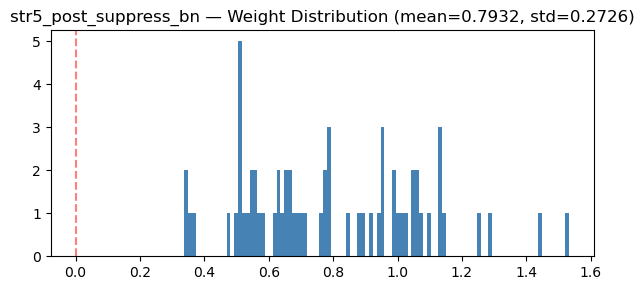

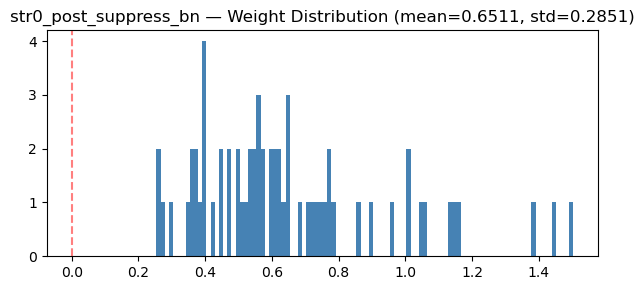

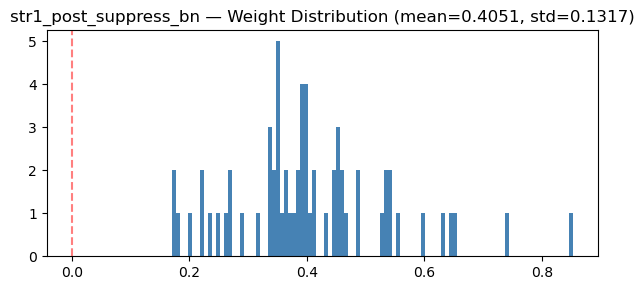

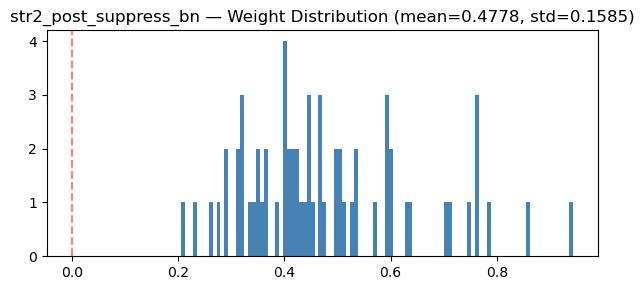

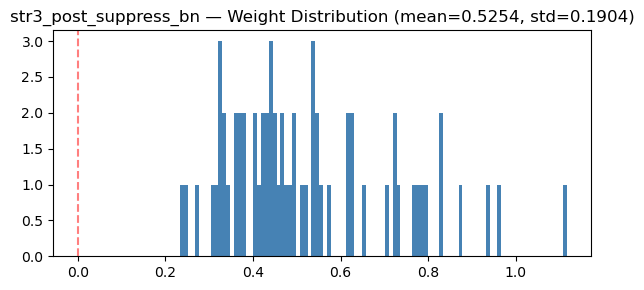

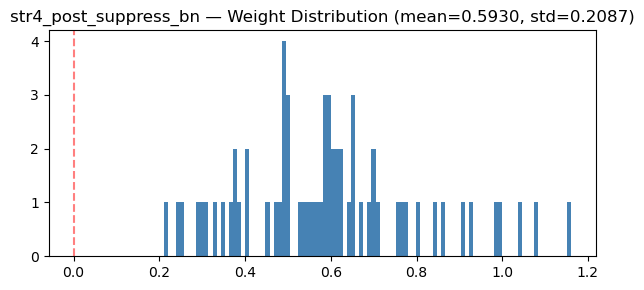

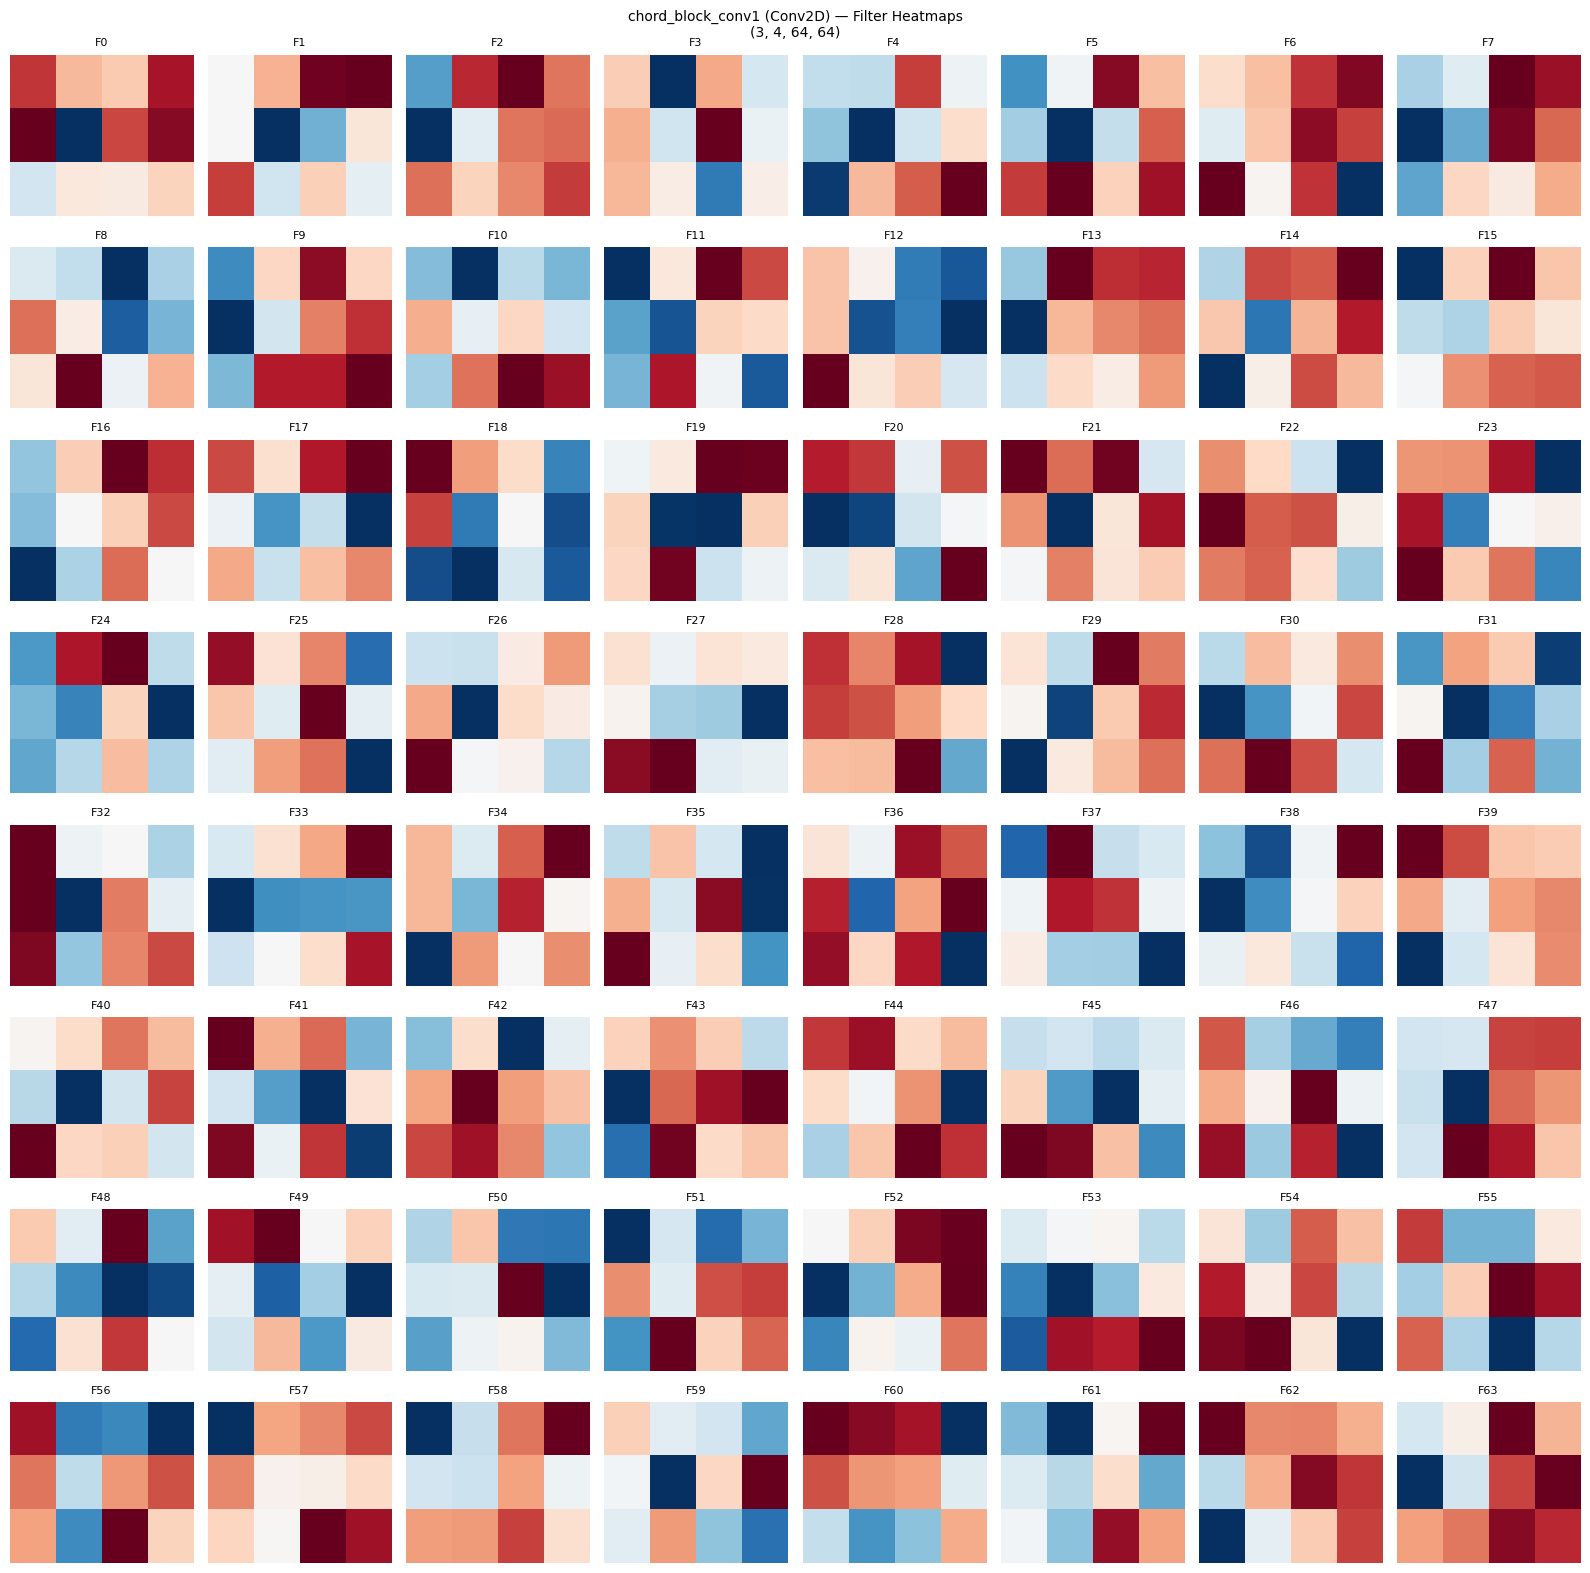

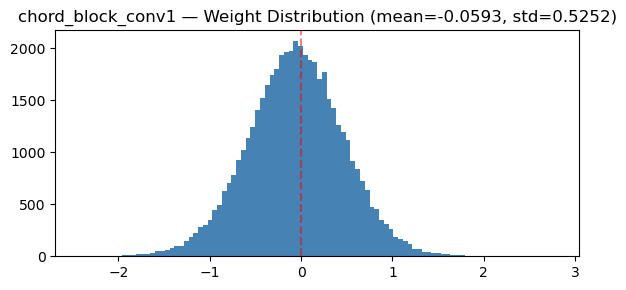

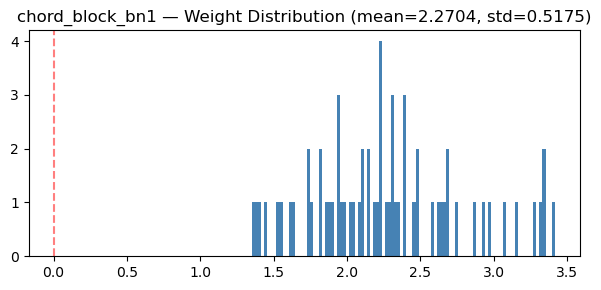

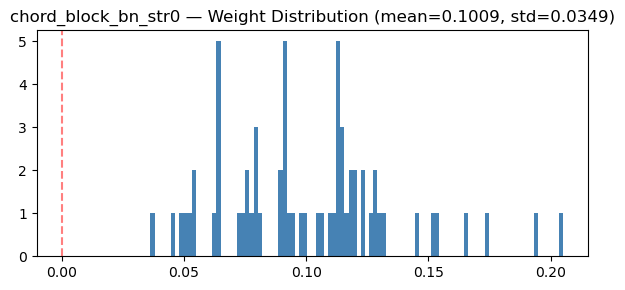

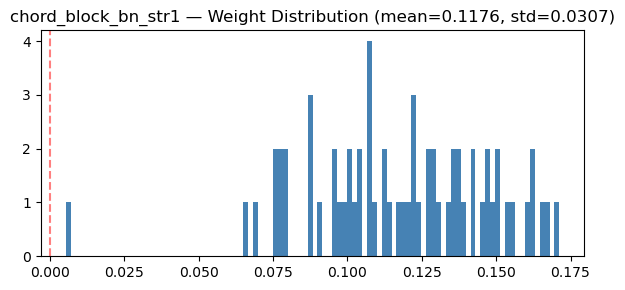

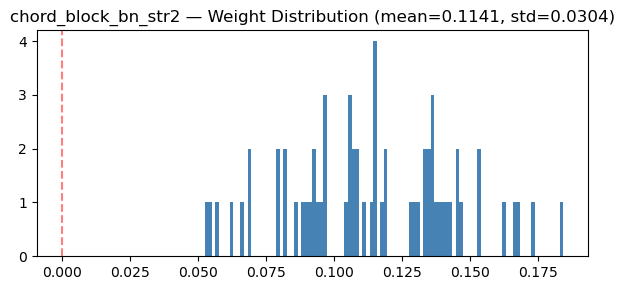

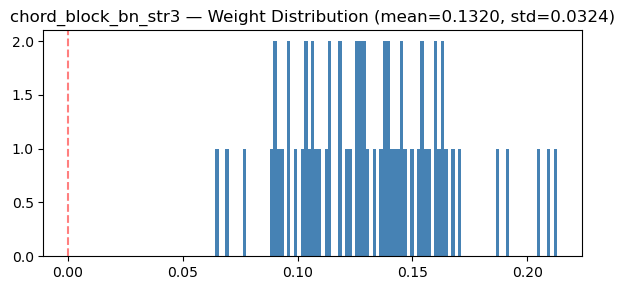

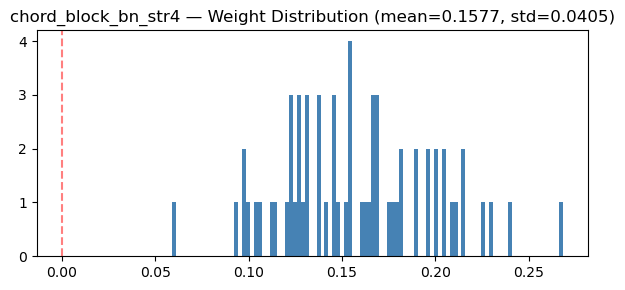

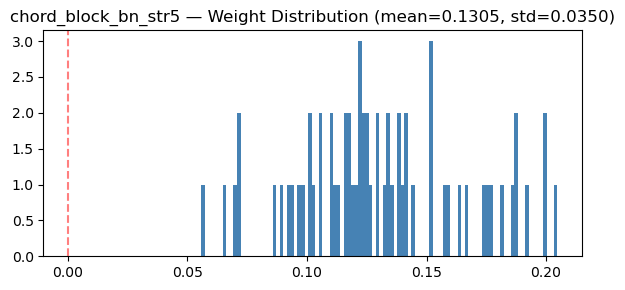

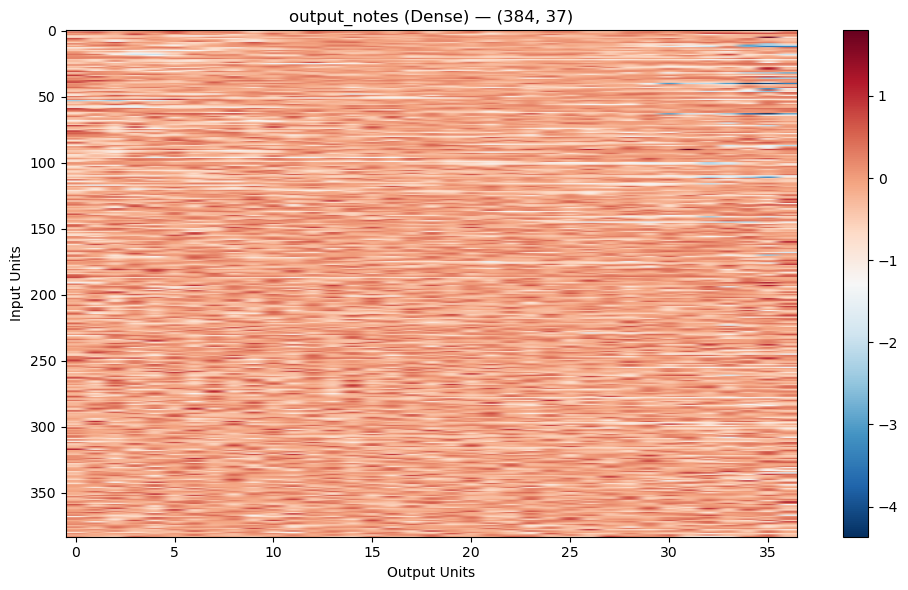

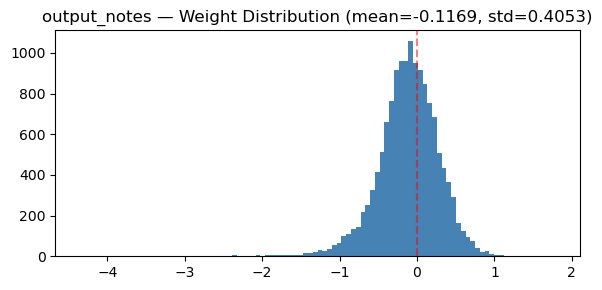

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step

--- Sample 0 ---
True notes: [21 25 28 33]
Top 10 predictions:
  note 24: 0.3168 
  note 20: 0.3113 
  note 22: 0.3084 
  note 26: 0.3039 
  note 25: 0.2537 ✓
  note 27: 0.2392 
  note 21: 0.2296 ✓
  note 34: 0.2295 
  note 19: 0.2107 
  note 31: 0.1989 
Max: 0.3168, Min: 0.0375, Mean: 0.1509, >0.5: 0
Std Dev: 0.0804
Total True Positives: 823
Total False Positives: 143
Total False Negatives: 2897
Precision: 0.8519668736971846
Recall: 0.22123655913919024


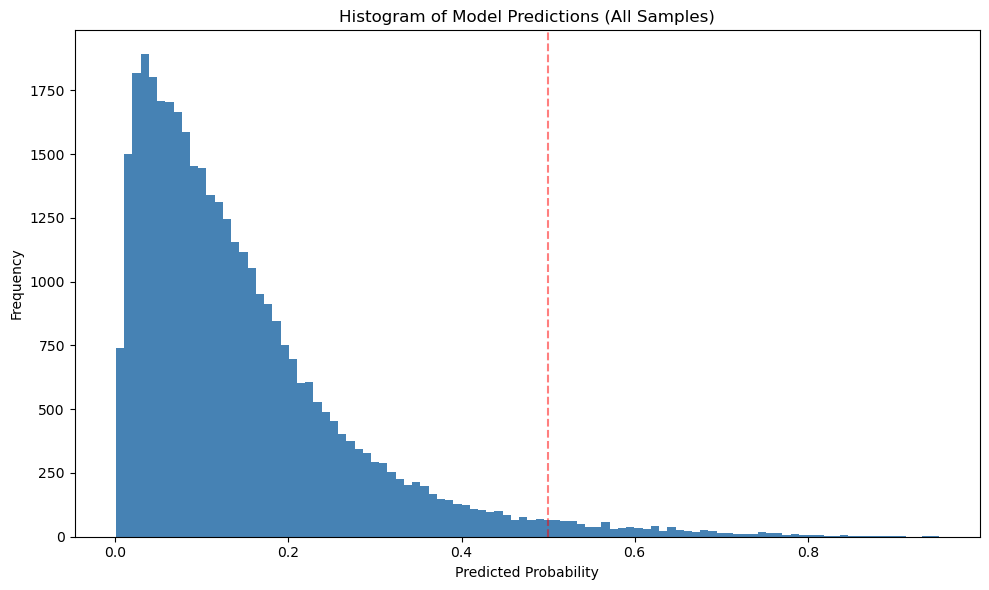

In [18]:
import tensorflow as tf
from tensorflow.data import TFRecordDataset 
import numpy as np
import os
import matplotlib.pyplot as plt
from common import fast_gpu_map,SAMPLERATE,feature_description

from model import build_1d_cnn_model
import common


BATCH_SIZE=1
recordfile="/data/test_subset/filtered_poly_data_64962.tfrecord"
model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_epoch85_valAcc0.9497_valPrec0.1417_valRecall0.9759.h5"#
#model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.weights.h5"

cnn_model=build_1d_cnn_model(BATCH_SIZE,common.INPUT_SHAPE,37,training=False)# common.OUTPUT_DIM_NOTES,training=False)
cnn_model.load_weights(model_weights)
for var in cnn_model.trainable_variables:
    var_id = getattr(var, 'path', var.name)
    if "freq_compress_conv2d" in var_id:
        print(var_id)

visualize_model_weights(cnn_model)

dataset=TFRecordDataset(recordfile)
def parse_example(example_proto):
    return tf.io.parse_single_example(example_proto, feature_description)
# Parse the dataset
dataset = dataset.map(parse_example)#.shuffle(buffer_size=10000,reshuffle_each_iteration=True)
dataset=dataset.map(lambda x: fast_gpu_map(x,training=False)).batch(BATCH_SIZE,drop_remainder=True).take(1000).prefetch(tf.data.AUTOTUNE)
#dataset=dataset.map(lambda path: fast_gpu_map(path, training=False)).take(100).prefetch(tf.data.AUTOTUNE)
#dataset = dataset.shuffle(BATCH_SIZE * 2).map(lambda path: fast_gpu_map(path, training=False), num_parallel_calls=tf.data.AUTOTUNE)
labels_true_all=[]
labels_pred_all=[]
total_tp=0
total_fp=0
total_fn=0

#Get the 7th tuple of the dataset (audio, label) and run a prediction

audio,label=None,None
element_idx=20
for idx, (audio_batch, label_batch) in enumerate(dataset):
    if idx == element_idx:
        x = audio_batch
        y_true = label_batch
        break

#plot_all_layer_activations(cnn_model, x)
y_pred = cnn_model.predict(x)

for i in range(len(y_true)):
    true_notes = np.where(y_true[i] > 0.5)[0]
    pred_raw = y_pred[i]
    
    # Show top 10 highest predictions
    top10 = np.argsort(pred_raw)[-10:][::-1]
    
    print(f"\n--- Sample {i} ---")
    print(f"True notes: {true_notes}")
    print(f"Top 10 predictions:")
    for idx in top10:
        print(f"  note {idx}: {pred_raw[idx]:.4f} {'✓' if idx in true_notes else ''}")
    
    # Show prediction stats
    print(f"Max: {pred_raw.max():.4f}, Min: {pred_raw.min():.4f}, "
          f"Mean: {pred_raw.mean():.4f}, >0.5: {(pred_raw > 0.5).sum()}")
    # Prediction standard deviation
    print(f"Std Dev: {pred_raw.std():.4f}")

for audio,label in dataset:
    # print("Audio shape:", audio.shape)
    pred=cnn_model.predict(audio,verbose=0)
    # print("Pred shape:", pred.shape)
    # print("Label shape:", label.shape)
    label=label.numpy()#.flatten()
    label=label[:,:37]
    pred=pred#.flatten()
    # print("flat Pred shape:", pred.shape)
    # print("flat Label shape:", label.shape)
    labels_true_all.append(label)
    labels_pred_all.append(pred)
    thresh=0.5
    label_active = label#[:88] # Assuming 88 notes
    pred_active = pred#[ :88]
    total_tp += np.sum((label_active == 1) & (pred_active > thresh))
    #total_tp+=np.sum((label==1) & (pred>thresh))
    total_fp+=np.sum((label_active==0)&(pred_active>thresh))
    total_fn+=np.sum((label_active==1)&(pred_active<=thresh))



print("Total True Positives:", total_tp)
print("Total False Positives:", total_fp)
print("Total False Negatives:", total_fn)
precision=total_tp/(total_tp+total_fp+1e-8)
recall=total_tp/(total_tp+total_fn+1e-8)
print("Precision:", precision)
print("Recall:", recall)


# Run predictions on the first 1000 samples and collect stats
predictions = []
for audio, label in dataset:
    pred = cnn_model.predict(audio, verbose=0)
    predictions.append(pred)

#create a histogram of the predictions
predictions = np.concatenate(predictions, axis=0)
plt.figure(figsize=(10, 6))
plt.hist(predictions.flatten(), bins=100, color='steelblue', edgecolor='none')
plt.title('Histogram of Model Predictions (All Samples)')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("predictions_histogram.png", dpi=150)
plt.show()


In [19]:
print("Length of labels_true_all:", len(labels_true_all))
labels_true=np.concatenate(labels_true_all,axis=0)
labels_pred=np.concatenate(labels_pred_all,axis=0)
labels_pred=(labels_pred>0.5).astype(np.float32)
print("Shape of labels true:",labels_true.shape)
#compute recall
tp=np.sum((labels_true==1) & (labels_pred==1),axis=0)

fp=np.sum((labels_true==0)&(labels_pred==1),axis=0)
fn=np.sum((labels_true==1)&(labels_pred==0),axis=0)
print("Shape of tp",tp.shape)

precision=tp/(tp+fp+1e-8)
print("precision:", precision)
recall=tp/(tp+fn+1e-8)
print("recall:", recall)
print("True Positives:", tp)
print("False Positives:", fp)

Length of labels_true_all: 1000
Shape of labels true: (1000, 37)
Shape of tp (37,)
precision: [0.97297297 0.         0.89473684 1.         0.75       0.92592593
 1.         0.82857143 0.86046512 0.5862069  0.95238095 0.75
 0.86138614 0.75       0.62162162 0.92941176 0.90909091 0.94117647
 0.83333333 0.71428571 0.95652174 0.         0.92727273 0.99999999
 0.57142857 0.33333333 0.4        0.88461538 0.         0.
 0.         0.91666667 0.         0.         0.         0.
 1.        ]
recall: [0.31034483 0.         0.27419355 0.13043478 1.         0.43103448
 0.25       0.1746988  0.21264368 0.25757576 0.32894737 0.16666667
 0.44845361 0.03409091 0.19491525 0.27241379 0.29411765 0.36697248
 0.03125    0.26666667 0.30136986 0.         0.41463415 0.01219512
 0.18181818 0.01086957 0.04166667 0.18548387 0.         0.
 0.         0.16666667 0.         0.         0.         0.
 0.1       ]
True Positives: [ 36   0  17  12   6  25   7  29  37  17 100   6  87   3  23  79  10  80
   5  40  44   0 

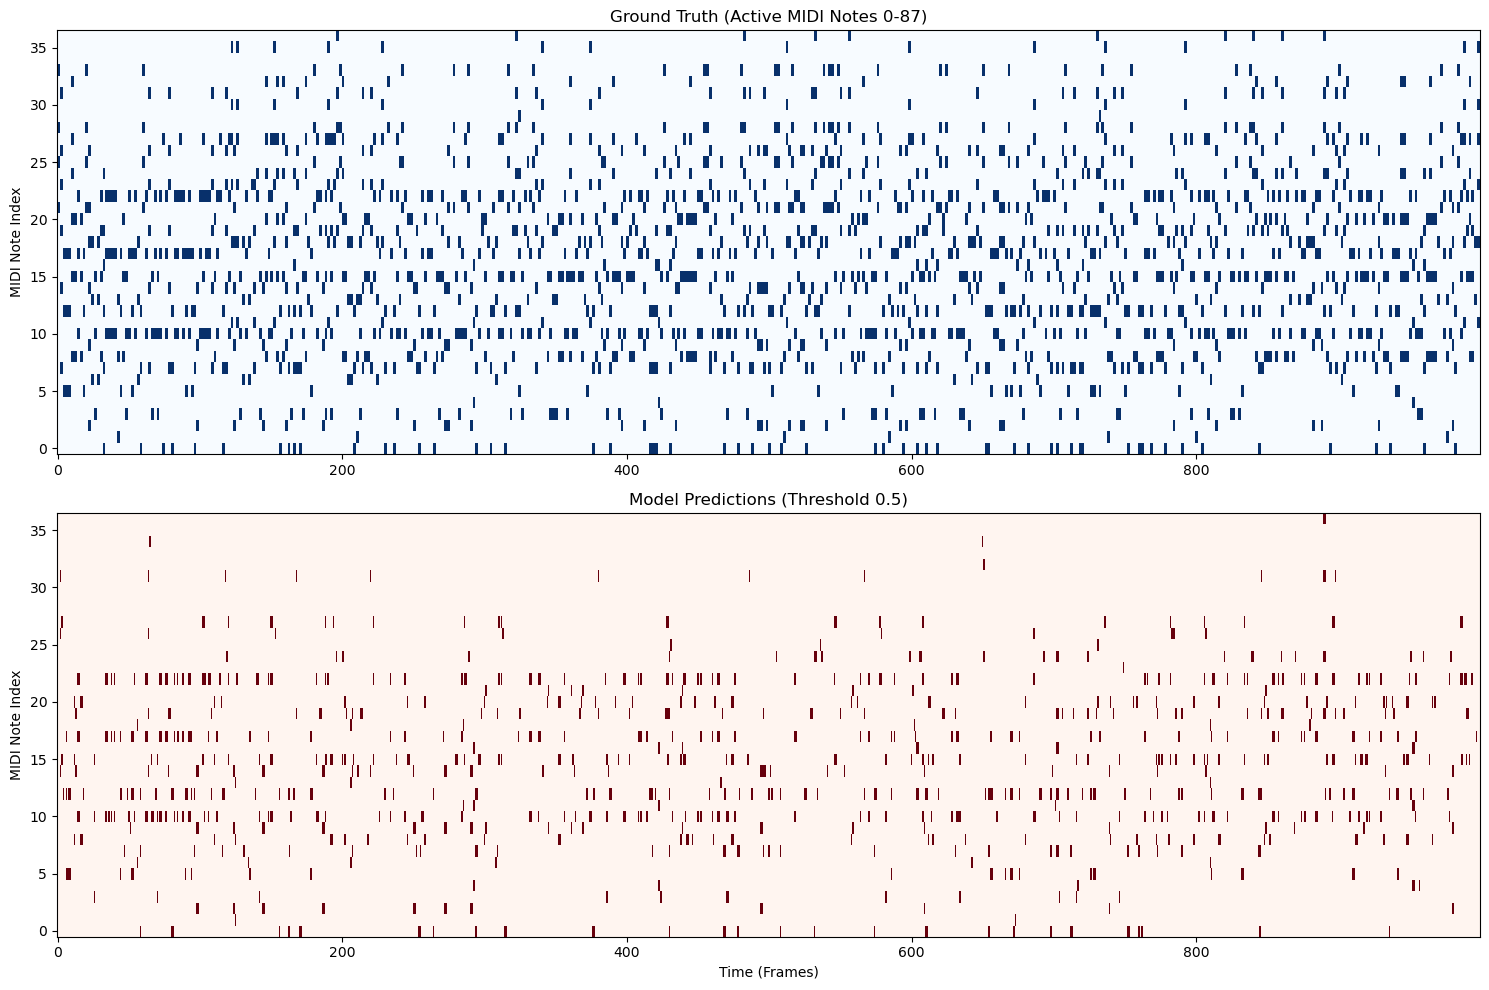

In [20]:
# Convert lists to single arrays
all_true = np.concatenate(labels_true_all, axis=0)[:, :88]
all_pred = np.concatenate(labels_pred_all, axis=0)[:, :88]

# Binary threshold for the plot
all_pred_bin = (all_pred > 0.5).astype(np.float32)

plt.figure(figsize=(15, 10))

# Plot Ground Truth (Blue)
plt.subplot(2, 1, 1)
plt.imshow(all_true.T, aspect='auto', origin='lower', cmap='Blues', interpolation='nearest')
plt.title("Ground Truth (Active MIDI Notes 0-87)")
plt.ylabel("MIDI Note Index")

# Plot Predictions (Red)
plt.subplot(2, 1, 2)
plt.imshow(all_pred_bin.T, aspect='auto', origin='lower', cmap='Reds', interpolation='nearest')
plt.title("Model Predictions (Threshold 0.5)")
plt.ylabel("MIDI Note Index")
plt.xlabel("Time (Frames)")

plt.tight_layout()
plt.show()